**Setup and Tasks 1-3: Load, Resize, and Convert to Grayscale**

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm import tqdm

# Mount Google Drive
drive.mount('/content/drive')

# Define dataset paths based on your Drive structure
base_path = '/content/drive/My Drive/Intro to CV/NEU Steel Surface Data'
train_img_dir = os.path.join(base_path, 'train_images')
valid_img_dir = os.path.join(base_path, 'valid_images')

# Target resolution for fast processing
IMG_SIZE = (64, 64)

def load_and_preprocess_data(image_dir):
    images = []
    labels = []

    if not os.path.exists(image_dir):
        print(f"Warning: Path {image_dir} does not exist. Please check your Drive path.")
        return np.array(images), np.array(labels)

    for filename in tqdm(os.listdir(image_dir), desc=f"Loading {os.path.basename(image_dir)}"):
        if filename.endswith('.jpg') or filename.endswith('.png'):
            img_path = os.path.join(image_dir, filename)

            img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_gray is None:
                continue

            # Task 2: Resize to a common resolution
            img_resized = cv2.resize(img_gray, IMG_SIZE)

            # Extract class label from filename (e.g., 'crazing_10.jpg' -> 'crazing')
            label = filename.split('_')[0]
            # Handle 'rolled-in_scale' which might have multiple underscores
            if 'rolled-in_scale' in filename:
                label = 'rolled-in_scale'

            images.append(img_resized)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load datasets
print("Loading Training Data...")
X_train_img, y_train_labels = load_and_preprocess_data(train_img_dir)
print("Loading Validation Data...")
X_valid_img, y_valid_labels = load_and_preprocess_data(valid_img_dir)

print(f"Loaded {len(X_train_img)} training images and {len(X_valid_img)} validation images.")

Mounted at /content/drive
Loading Training Data...


Loading train_images: 100%|██████████| 1700/1700 [00:29<00:00, 57.89it/s] 


Loading Validation Data...


Loading valid_images: 100%|██████████| 100/100 [00:03<00:00, 31.79it/s]

Loaded 1700 training images and 100 validation images.


**Tasks 4-5: Extract HOG Features and Visualize** <br>
This cell extracts the base HOG representation and visualizes a representative image.

Extracting HOG for training set...


Extracting HOG: 100%|██████████| 1700/1700 [00:04<00:00, 386.48it/s]


Extracting HOG for validation set...


Extracting HOG: 100%|██████████| 100/100 [00:00<00:00, 609.55it/s]


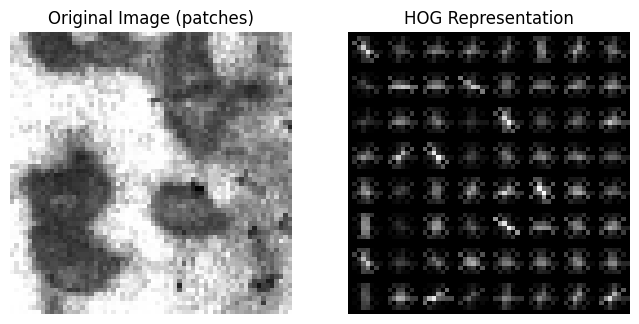

In [2]:
from skimage.feature import hog

def extract_hog_features(images, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    hog_features = []
    for img in tqdm(images, desc="Extracting HOG"):
        features = hog(img, orientations=orientations,
                       pixels_per_cell=pixels_per_cell,
                       cells_per_block=cells_per_block,
                       block_norm='L2-Hys', visualize=False)
        hog_features.append(features)
    return np.array(hog_features)

# Extract features for train and validation sets
print("Extracting HOG for training set...")
X_train_hog = extract_hog_features(X_train_img)
print("Extracting HOG for validation set...")
X_valid_hog = extract_hog_features(X_valid_img)

# Task 5: Visualize HOG representation
if len(X_train_img) > 0:
    sample_img = X_train_img[0]
    sample_label = y_train_labels[0]

    _, hog_image = hog(sample_img, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
    ax1.axis('off')
    ax1.imshow(sample_img, cmap=plt.cm.gray)
    ax1.set_title(f'Original Image ({sample_label})')

    ax2.axis('off')
    ax2.imshow(hog_image, cmap=plt.cm.gray)
    ax2.set_title('HOG Representation')
    plt.show()

**Tasks 6-7: Train SVM and XGBoost Classifiers**

In [3]:
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode string labels to numeric for XGBoost
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_labels)
y_valid_encoded = le.transform(y_valid_labels)

# Task 6: Train an SVM classifier using HOG features
print("Training SVM Classifier...")
svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train_hog, y_train_encoded)
print("SVM Training Complete.")

# Task 7: Train XGBoost classifier
print("Training XGBoost Classifier...")
xgb_clf = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
xgb_clf.fit(X_train_hog, y_train_encoded)
print("XGBoost Training Complete.")

Training SVM Classifier...
SVM Training Complete.
Training XGBoost Classifier...
XGBoost Training Complete.


**Tasks 8-10: Classifier Comparison, Confusion Matrix, and Classification Report**

=== CLASSIFIER PERFORMANCE COMPARISON ===


,Metric,SVM (HOG),XGBoost (HOG)
0,Accuracy,0.9000,0.8600
1,Precision (Weighted),0.9056,0.8726
2,Recall (Weighted),0.9000,0.8600
3,F1-Score (Weighted),0.8965,0.8626



=== SVM CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

        crazing       0.89      0.94      0.91        17
      inclusion       0.80      0.94      0.86        17
        patches       0.94      1.00      0.97        16
         pitted       0.92      0.65      0.76        17
rolled-in_scale       0.89      1.00      0.94        17
      scratches       1.00      0.88      0.93        16

       accuracy                           0.90       100
      macro avg       0.91      0.90      0.90       100
   weighted avg       0.91      0.90      0.90       100



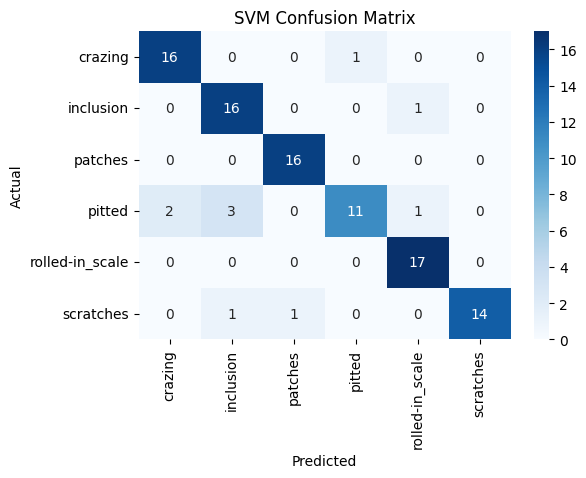


=== XGBOOST CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

        crazing       0.78      0.82      0.80        17
      inclusion       0.76      0.94      0.84        17
        patches       1.00      0.88      0.93        16
         pitted       0.78      0.82      0.80        17
rolled-in_scale       0.93      0.82      0.88        17
      scratches       1.00      0.88      0.93        16

       accuracy                           0.86       100
      macro avg       0.88      0.86      0.86       100
   weighted avg       0.87      0.86      0.86       100



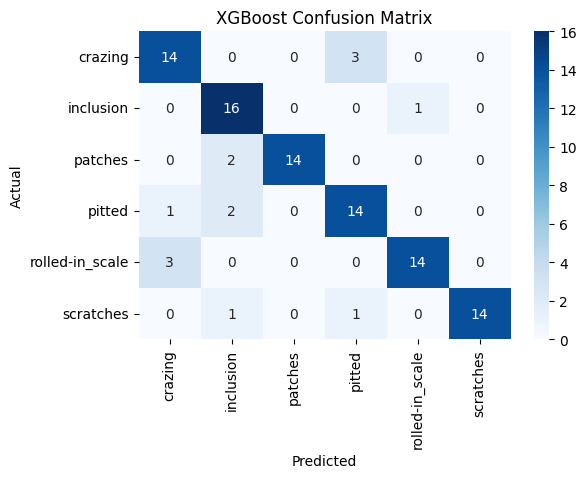

In [4]:
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    return y_pred, acc, prec, rec, f1

# Evaluate SVM
svm_pred, svm_acc, svm_prec, svm_rec, svm_f1 = evaluate_model(svm_clf, X_valid_hog, y_valid_encoded)

# Evaluate XGBoost
xgb_pred, xgb_acc, xgb_prec, xgb_rec, xgb_f1 = evaluate_model(xgb_clf, X_valid_hog, y_valid_encoded)

# Task 8 & 10: Tabular Comparison
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)'],
    'SVM (HOG)': [f"{svm_acc:.4f}", f"{svm_prec:.4f}", f"{svm_rec:.4f}", f"{svm_f1:.4f}"],
    'XGBoost (HOG)': [f"{xgb_acc:.4f}", f"{xgb_prec:.4f}", f"{xgb_rec:.4f}", f"{xgb_f1:.4f}"]
})
print("=== CLASSIFIER PERFORMANCE COMPARISON ===")
display(metrics_df)

# Task 9: Classification Reports and Confusion Matrices
def plot_cm(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

print("\n=== SVM CLASSIFICATION REPORT ===")
print(classification_report(y_valid_encoded, svm_pred, target_names=le.classes_))
plot_cm(y_valid_encoded, svm_pred, le.classes_, "SVM Confusion Matrix")

print("\n=== XGBOOST CLASSIFICATION REPORT ===")
print(classification_report(y_valid_encoded, xgb_pred, target_names=le.classes_))
plot_cm(y_valid_encoded, xgb_pred, le.classes_, "XGBoost Confusion Matrix")

**Task 11: HOG Parameter Experiments**

In [5]:
from sklearn.svm import LinearSVC

cell_sizes = [(4, 4), (8, 8), (16, 16)]
orientations_list = [6, 9, 12]

results = []

print("Running HOG Parameter Experiments (using LinearSVC for speed)...")
for cell in cell_sizes:
    for ori in orientations_list:
        # Extract features
        X_tr_exp = extract_hog_features(X_train_img, orientations=ori, pixels_per_cell=cell)
        X_val_exp = extract_hog_features(X_valid_img, orientations=ori, pixels_per_cell=cell)

        # Train and Evaluate
        clf = LinearSVC(random_state=42, dual=False)
        clf.fit(X_tr_exp, y_train_encoded)
        y_pred_exp = clf.predict(X_val_exp)

        acc = accuracy_score(y_valid_encoded, y_pred_exp)
        results.append({'Cell Size': f"{cell[0]}x{cell[1]}", 'Orientations': ori, 'Accuracy': acc})

exp_df = pd.DataFrame(results)
print("\n=== HOG PARAMETER EXPERIMENT RESULTS ===")
display(exp_df)

Running HOG Parameter Experiments (using LinearSVC for speed)...


Extracting HOG: 100%|██████████| 100/100 [00:00<00:00, 867.97it/s]



=== HOG PARAMETER EXPERIMENT RESULTS ===


,Cell Size,Orientations,Accuracy
0,4x4,6,0.52
1,4x4,9,0.49
2,4x4,12,0.56
3,8x8,6,0.69
4,8x8,9,0.62
5,8x8,12,0.74
6,16x16,6,0.71
7,16x16,9,0.74
8,16x16,12,0.74


**Task 12: Robustness Evaluation**

In [6]:
from scipy.ndimage import rotate

def apply_brightness(img, factor=1.5):
    return np.clip(img * factor, 0, 255).astype(np.uint8)

def apply_noise(img):
    noise = np.random.normal(0, 25, img.shape)
    return np.clip(img + noise, 0, 255).astype(np.uint8)

def apply_rotation(img, angle=15):
    # Rotate and crop back to original size
    rotated = rotate(img, angle, reshape=False)
    return np.clip(rotated, 0, 255).astype(np.uint8)

def apply_blur(img):
    return cv2.GaussianBlur(img, (5, 5), 0)

corruptions = {
    "Brightness Variation": apply_brightness,
    "Gaussian Noise": apply_noise,
    "Rotation (15 deg)": apply_rotation,
    "Blur": apply_blur
}

robustness_results = []
baseline_acc = xgb_acc
baseline_f1 = xgb_f1

print("Running Robustness Evaluation on XGBoost...")

for name, func in corruptions.items():
    # Apply corruption
    X_val_corrupt = np.array([func(img) for img in X_valid_img])

    # Extract HOG
    X_val_corrupt_hog = extract_hog_features(X_val_corrupt)

    # Predict
    y_pred_c = xgb_clf.predict(X_val_corrupt_hog)
    acc = accuracy_score(y_valid_encoded, y_pred_c)
    _, _, f1, _ = precision_recall_fscore_support(y_valid_encoded, y_pred_c, average='weighted', zero_division=0)

    robustness_results.append({
        'Condition': name,
        'Accuracy': acc,
        'Acc Drop': baseline_acc - acc,
        'F1-Score': f1,
        'F1 Drop': baseline_f1 - f1
    })

robust_df = pd.DataFrame(robustness_results)
print("\n=== ROBUSTNESS ANALYSIS (Compared to Baseline XGBoost) ===")
display(robust_df)

Running Robustness Evaluation on XGBoost...


Extracting HOG: 100%|██████████| 100/100 [00:00<00:00, 319.76it/s]


=== ROBUSTNESS ANALYSIS (Compared to Baseline XGBoost) ===


,Condition,Accuracy,Acc Drop,F1-Score,F1 Drop
0,Brightness Variation,0.63,0.23,0.629802,0.232772
1,Gaussian Noise,0.24,0.62,0.168084,0.694491
2,Rotation (15 deg),0.38,0.48,0.323624,0.538950
3,Blur,0.38,0.48,0.298371,0.564204


**Task 13: Industrial Quality-Control Decision Module**

In [9]:
def inspect_product(image, model, encoder):
    # Ensure image is in right format
    if len(image.shape) > 2:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = cv2.resize(image, IMG_SIZE)

    # Extract feature
    feature = hog(image, orientations=9, pixels_per_cell=(8, 8),
                  cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)

    # Predict
    probs = model.predict_proba([feature])[0]
    pred_idx = np.argmax(probs)
    confidence = probs[pred_idx] * 100
    predicted_class = encoder.inverse_transform([pred_idx])[0]

    # Since NEU-DET consists entirely of defect classes, detecting any class implies a defect.
    # If you introduce a "normal" class later, you would add `if predicted_class == 'normal':`

    status = "DEFECTIVE"
    action = "REJECT PRODUCT"

    print("PRODUCT INSPECTION RESULT")
    print(f"Prediction: {status} ({predicted_class})")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Action: {action}")
    print("-" * 30)

# Test the module on a few validation images
print("\nTesting Final Decision Module:\n")
if len(X_valid_img) >= 3:
    for i in range(3):
        inspect_product(X_valid_img[i], xgb_clf, le)


Testing Final Decision Module:

PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (crazing)
Confidence: 65.80%
Action: REJECT PRODUCT
------------------------------
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (crazing)
Confidence: 32.28%
Action: REJECT PRODUCT
------------------------------
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (crazing)
Confidence: 36.41%
Action: REJECT PRODUCT
------------------------------
